[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hien078/applied-mathematics-foundation/blob/master/graph_theory/computation.ipynb)

# Computation: Graph Theory

Interactive demonstrations of graph theory concepts using Python and NetworkX.

**Topics covered:**
1. Graph construction and basic operations
2. Adjacency matrix visualization
3. BFS and DFS implementation and visualization
4. Dijkstra's shortest path
5. Minimum spanning tree
6. Real-world network example (social network)

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from collections import deque

rng = np.random.default_rng(seed=42)

# Plot settings
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

---
## 1. Graph Construction with NetworkX

We start by building graphs and exploring their basic properties.

### 1.1 Undirected Graph

Vertices: [1, 2, 3, 4, 5, 6]
Edges:    [(1, 2), (1, 3), (2, 3), (2, 4), (3, 4), (3, 5), (4, 5), (4, 6), (5, 6)]
Order (|V|): 6
Size  (|E|): 9


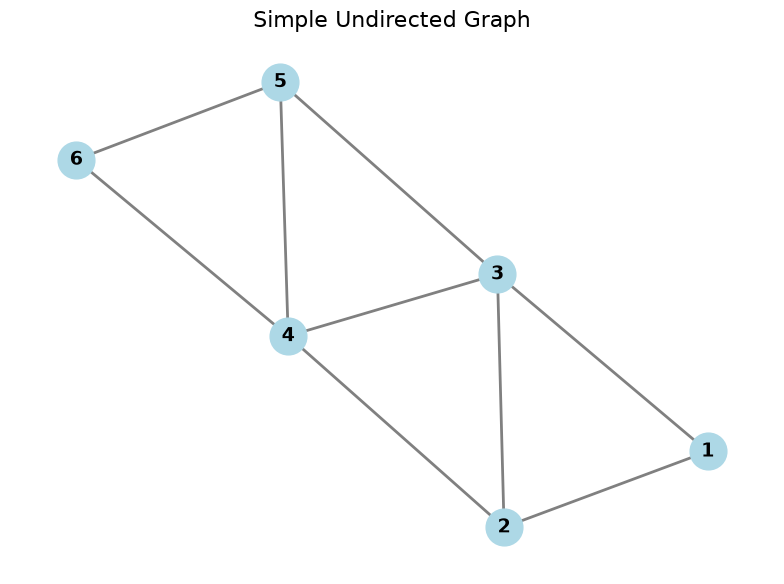

In [2]:
# Create a simple undirected graph
G = nx.Graph()

# Add vertices (nodes)
G.add_nodes_from([1, 2, 3, 4, 5, 6])

# Add edges
G.add_edges_from([
    (1, 2), (1, 3), (2, 3), (2, 4),
    (3, 4), (3, 5), (4, 5), (4, 6), (5, 6)
])

print(f"Vertices: {list(G.nodes())}")
print(f"Edges:    {list(G.edges())}")
print(f"Order (|V|): {G.number_of_nodes()}")
print(f"Size  (|E|): {G.number_of_edges()}")

# Draw the graph
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, ax=ax, with_labels=True, node_color='lightblue',
        node_size=700, font_size=14, font_weight='bold',
        edge_color='gray', width=2)
ax.set_title('Simple Undirected Graph', fontsize=16)
plt.tight_layout()
plt.show()

### 1.2 Directed Graph

Directed graph:
  Node 1: in-degree=0, out-degree=2
  Node 2: in-degree=2, out-degree=1
  Node 3: in-degree=1, out-degree=2
  Node 4: in-degree=2, out-degree=1
  Node 5: in-degree=2, out-degree=1
  Node 6: in-degree=1, out-degree=1


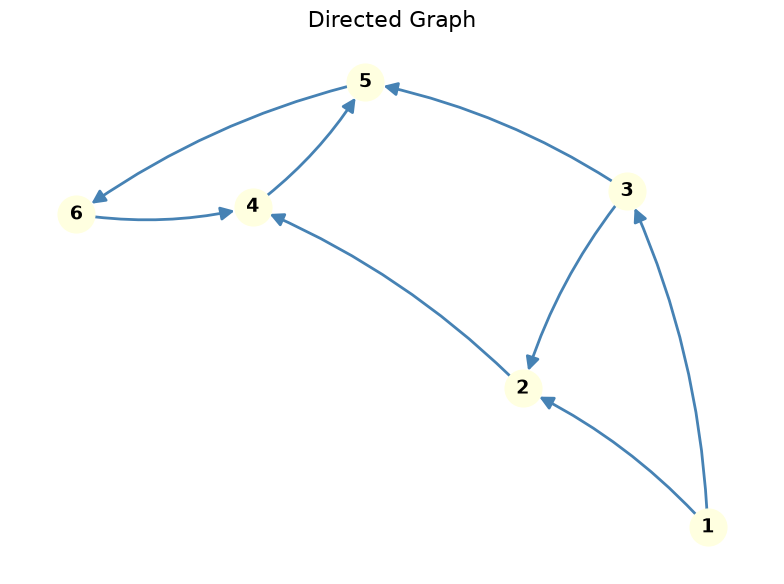

In [3]:
# Create a directed graph
D = nx.DiGraph()
D.add_edges_from([
    (1, 2), (1, 3), (2, 4), (3, 2),
    (3, 5), (4, 5), (5, 6), (6, 4)
])

print("Directed graph:")
for v in sorted(D.nodes()):
    print(f"  Node {v}: in-degree={D.in_degree(v)}, out-degree={D.out_degree(v)}")

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
pos_d = nx.spring_layout(D, seed=42)
nx.draw(D, pos_d, ax=ax, with_labels=True, node_color='lightyellow',
        node_size=700, font_size=14, font_weight='bold',
        edge_color='steelblue', width=2, arrowsize=20,
        connectionstyle='arc3,rad=0.1')
ax.set_title('Directed Graph', fontsize=16)
plt.tight_layout()
plt.show()

### 1.3 Weighted Graph

Weighted edges:
  A -- B: weight = 4
  A -- C: weight = 2
  B -- C: weight = 1
  B -- D: weight = 5
  C -- D: weight = 8
  C -- E: weight = 10
  D -- E: weight = 2
  D -- F: weight = 6
  E -- F: weight = 3


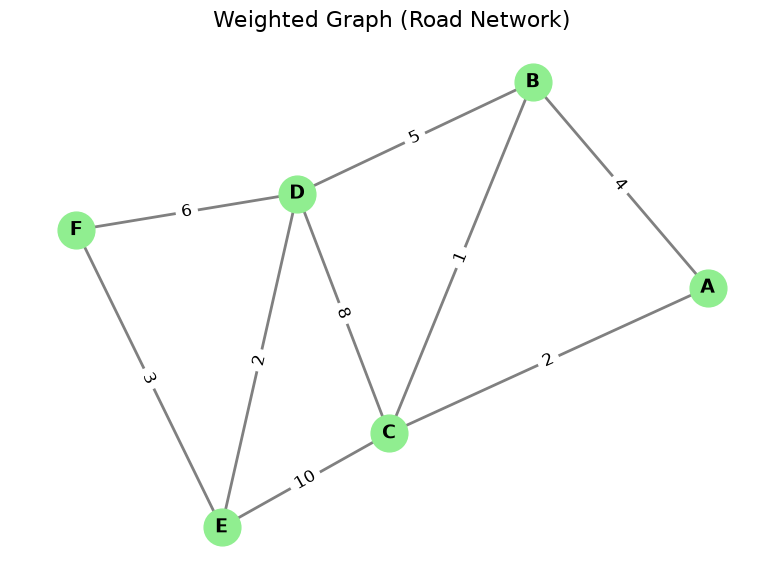

In [4]:
# Create a weighted graph (small road network)
W = nx.Graph()
weighted_edges = [
    ('A', 'B', 4), ('A', 'C', 2), ('B', 'C', 1),
    ('B', 'D', 5), ('C', 'D', 8), ('C', 'E', 10),
    ('D', 'E', 2), ('D', 'F', 6), ('E', 'F', 3)
]
W.add_weighted_edges_from(weighted_edges)

print("Weighted edges:")
for u, v, data in W.edges(data=True):
    print(f"  {u} -- {v}: weight = {data['weight']}")

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
pos_w = nx.spring_layout(W, seed=42)
nx.draw(W, pos_w, ax=ax, with_labels=True, node_color='lightgreen',
        node_size=700, font_size=14, font_weight='bold',
        edge_color='gray', width=2)
edge_labels = nx.get_edge_attributes(W, 'weight')
nx.draw_networkx_edge_labels(W, pos_w, edge_labels=edge_labels,
                              font_size=12, ax=ax)
ax.set_title('Weighted Graph (Road Network)', fontsize=16)
plt.tight_layout()
plt.show()

### 1.4 Graph Properties: Degree and Handshaking Lemma

In [5]:
# Verify the Handshaking Lemma: sum of degrees = 2 * |E|
degrees = dict(G.degree())
print("Degree sequence:")
for v, d in sorted(degrees.items()):
    print(f"  deg({v}) = {d}")

sum_degrees = sum(degrees.values())
twice_edges = 2 * G.number_of_edges()

print(f"\nSum of degrees:  {sum_degrees}")
print(f"2 * |E|:         {twice_edges}")
print(f"Handshaking Lemma verified: {sum_degrees == twice_edges}")

# Count vertices with odd degree
odd_degree_count = sum(1 for d in degrees.values() if d % 2 == 1)
print(f"\nVertices with odd degree: {odd_degree_count} (must be even)")

Degree sequence:
  deg(1) = 2
  deg(2) = 3
  deg(3) = 4
  deg(4) = 4
  deg(5) = 3
  deg(6) = 2

Sum of degrees:  18
2 * |E|:         18
Handshaking Lemma verified: True

Vertices with odd degree: 2 (must be even)


---
## 2. Adjacency Matrix Visualization

The adjacency matrix $A$ is the most important algebraic representation of a graph.
We verify key properties including $A = A^\top$ (symmetry) and the walk-counting theorem.

In [6]:
# Get adjacency matrix
A = nx.adjacency_matrix(G, nodelist=sorted(G.nodes())).toarray()

print("Adjacency matrix A:")
print(A)
print(f"\nShape: {A.shape}")
print(f"Symmetric (A = A^T): {np.array_equal(A, A.T)}")
print(f"Diagonal is zero (no self-loops): {np.all(np.diag(A) == 0)}")

Adjacency matrix A:
[[0 1 1 0 0 0]
 [1 0 1 1 0 0]
 [1 1 0 1 1 0]
 [0 1 1 0 1 1]
 [0 0 1 1 0 1]
 [0 0 0 1 1 0]]

Shape: (6, 6)
Symmetric (A = A^T): True
Diagonal is zero (no self-loops): True


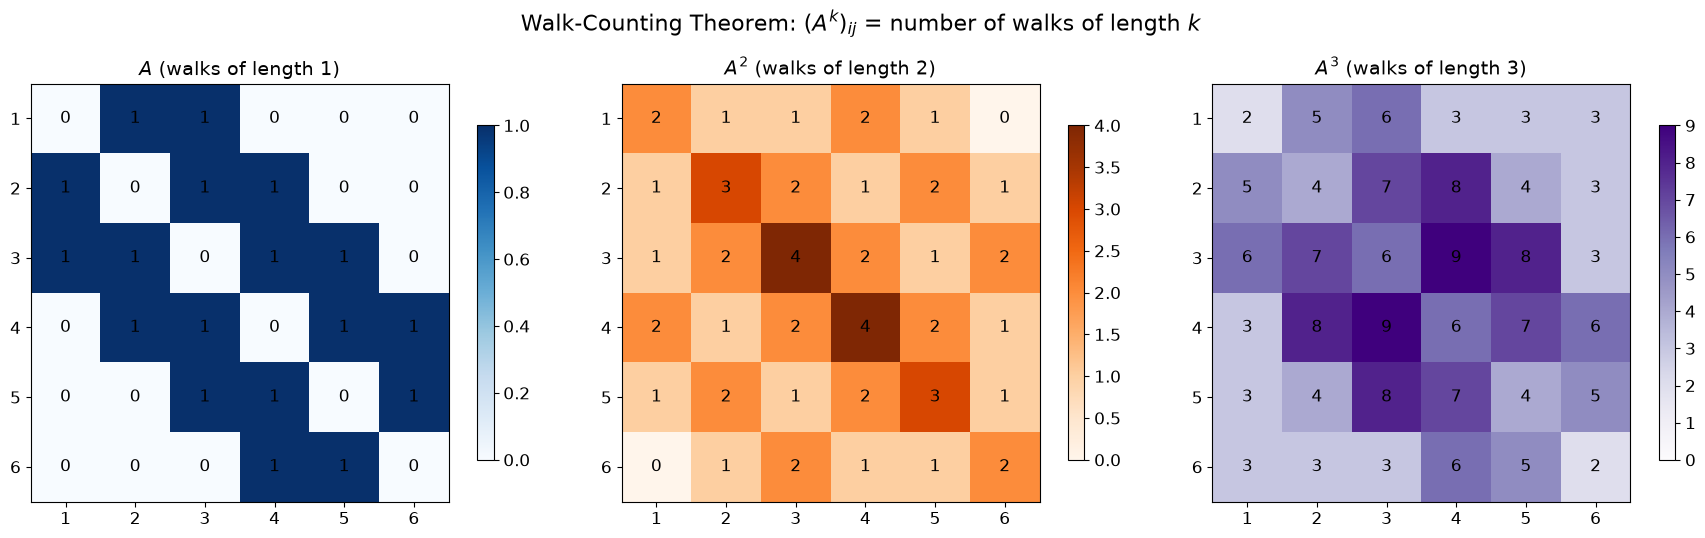


Walks of length 2 from node 1 to node 4: (A^2)[0,3] = 2
Manual check: 1→2→4 and 1→3→4 — that's 2 walks ✓


In [7]:
# Visualize adjacency matrix as heatmap
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

labels = sorted(G.nodes())

# A^1 — edges (walks of length 1)
im0 = axes[0].imshow(A, cmap='Blues', vmin=0)
axes[0].set_title('$A$ (walks of length 1)', fontsize=14)
axes[0].set_xticks(range(len(labels)))
axes[0].set_yticks(range(len(labels)))
axes[0].set_xticklabels(labels)
axes[0].set_yticklabels(labels)
for i in range(len(labels)):
    for j in range(len(labels)):
        axes[0].text(j, i, str(A[i, j]), ha='center', va='center', fontsize=12)
plt.colorbar(im0, ax=axes[0], shrink=0.8)

# A^2 — walks of length 2
A2 = A @ A
im1 = axes[1].imshow(A2, cmap='Oranges', vmin=0)
axes[1].set_title('$A^2$ (walks of length 2)', fontsize=14)
axes[1].set_xticks(range(len(labels)))
axes[1].set_yticks(range(len(labels)))
axes[1].set_xticklabels(labels)
axes[1].set_yticklabels(labels)
for i in range(len(labels)):
    for j in range(len(labels)):
        axes[1].text(j, i, str(A2[i, j]), ha='center', va='center', fontsize=12)
plt.colorbar(im1, ax=axes[1], shrink=0.8)

# A^3 — walks of length 3
A3 = A @ A @ A
im2 = axes[2].imshow(A3, cmap='Purples', vmin=0)
axes[2].set_title('$A^3$ (walks of length 3)', fontsize=14)
axes[2].set_xticks(range(len(labels)))
axes[2].set_yticks(range(len(labels)))
axes[2].set_xticklabels(labels)
axes[2].set_yticklabels(labels)
for i in range(len(labels)):
    for j in range(len(labels)):
        axes[2].text(j, i, str(A3[i, j]), ha='center', va='center', fontsize=12)
plt.colorbar(im2, ax=axes[2], shrink=0.8)

plt.suptitle('Walk-Counting Theorem: $(A^k)_{ij}$ = number of walks of length $k$',
             fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# Verify: A^2[0,3] = number of walks of length 2 from node 1 to node 4
print(f"\nWalks of length 2 from node 1 to node 4: (A^2)[0,3] = {A2[0, 3]}")
print("Manual check: 1→2→4 and 1→3→4 — that's 2 walks ✓")

In [8]:
# Graph Laplacian: L = D - A
D_mat = np.diag([G.degree(v) for v in sorted(G.nodes())])
L = D_mat - A

print("Degree matrix D:")
print(D_mat)
print("\nLaplacian L = D - A:")
print(L)

# Eigenvalues of Laplacian
eigenvalues = np.sort(np.linalg.eigvalsh(L))
print(f"\nLaplacian eigenvalues: {np.round(eigenvalues, 4)}")
print(f"Smallest eigenvalue (always 0 for connected graph): {eigenvalues[0]:.6f}")
print(f"Second smallest (algebraic connectivity): {eigenvalues[1]:.4f}")
print(f"Graph is connected: {eigenvalues[1] > 1e-10}")

Degree matrix D:
[[2 0 0 0 0 0]
 [0 3 0 0 0 0]
 [0 0 4 0 0 0]
 [0 0 0 4 0 0]
 [0 0 0 0 3 0]
 [0 0 0 0 0 2]]

Laplacian L = D - A:
[[ 2 -1 -1  0  0  0]
 [-1  3 -1 -1  0  0]
 [-1 -1  4 -1 -1  0]
 [ 0 -1 -1  4 -1 -1]
 [ 0  0 -1 -1  3 -1]
 [ 0  0  0 -1 -1  2]]

Laplacian eigenvalues: [-0.      1.1864  3.      3.4707  5.      5.3429]
Smallest eigenvalue (always 0 for connected graph): -0.000000
Second smallest (algebraic connectivity): 1.1864
Graph is connected: True


---
## 3. BFS and DFS: Implementation and Visualization

We implement BFS and DFS from scratch and visualize the order in which vertices are explored.

### 3.1 BFS (Breadth-First Search)

In [9]:
def bfs(graph, source):
    """
    Breadth-First Search from source vertex.

    Returns:
        dist: dict mapping vertex -> shortest distance from source
        parent: dict mapping vertex -> parent in BFS tree
        order: list of vertices in BFS visit order
    """
    dist = {v: float('inf') for v in graph.nodes()}
    parent = {v: None for v in graph.nodes()}
    dist[source] = 0
    order = []

    queue = deque([source])

    while queue:
        u = queue.popleft()
        order.append(u)

        for v in graph.neighbors(u):
            if dist[v] == float('inf'):  # Not visited
                dist[v] = dist[u] + 1
                parent[v] = u
                queue.append(v)

    return dist, parent, order


# Run BFS from node 1
bfs_dist, bfs_parent, bfs_order = bfs(G, source=1)

print("BFS from node 1:")
print(f"  Visit order: {bfs_order}")
print(f"  Distances:   {dict(sorted(bfs_dist.items()))}")
print(f"  Parents:     {dict(sorted(bfs_parent.items()))}")

BFS from node 1:
  Visit order: [1, 2, 3, 4, 5, 6]
  Distances:   {1: 0, 2: 1, 3: 1, 4: 2, 5: 2, 6: 3}
  Parents:     {1: None, 2: 1, 3: 1, 4: 2, 5: 3, 6: 4}


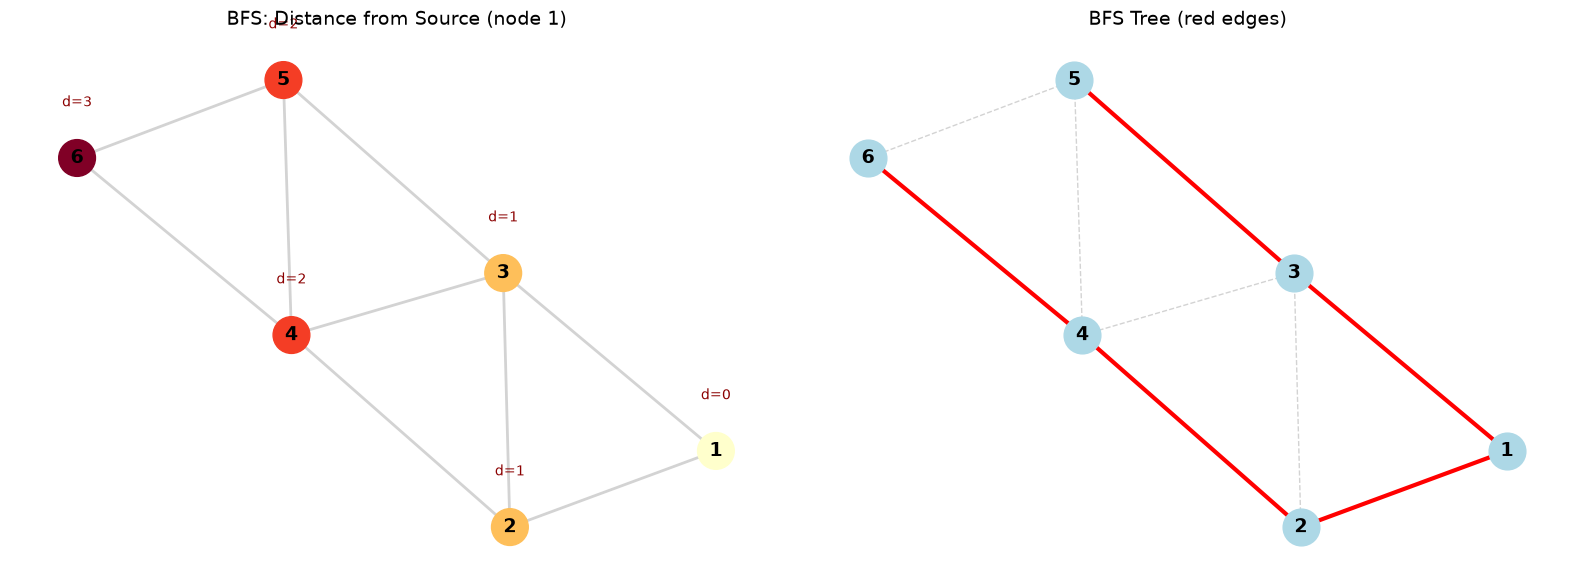

In [10]:
# Visualize BFS traversal
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: BFS order with distance coloring
colors = [bfs_dist[v] for v in sorted(G.nodes())]
nx.draw(G, pos, ax=axes[0], with_labels=True,
        node_color=colors, cmap=plt.cm.YlOrRd,
        node_size=700, font_size=14, font_weight='bold',
        edge_color='lightgray', width=2)

# Add distance labels
for v in G.nodes():
    x, y = pos[v]
    axes[0].text(x, y + 0.12, f'd={bfs_dist[v]}', ha='center',
                fontsize=10, color='darkred')
axes[0].set_title('BFS: Distance from Source (node 1)', fontsize=14)

# Right: BFS tree
bfs_tree_edges = [(bfs_parent[v], v) for v in G.nodes() if bfs_parent[v] is not None]
T_bfs = nx.Graph()
T_bfs.add_nodes_from(G.nodes())
T_bfs.add_edges_from(bfs_tree_edges)

nx.draw(G, pos, ax=axes[1], with_labels=True,
        node_color='lightblue', node_size=700, font_size=14, font_weight='bold',
        edge_color='lightgray', width=1, style='dashed')
nx.draw_networkx_edges(T_bfs, pos, ax=axes[1],
                        edge_color='red', width=3)
axes[1].set_title('BFS Tree (red edges)', fontsize=14)

plt.tight_layout()
plt.show()

### 3.2 DFS (Depth-First Search)

In [11]:
def dfs(graph, source):
    """
    Depth-First Search from source vertex (iterative, using stack).

    Returns:
        visited: set of visited vertices
        parent: dict mapping vertex -> parent in DFS tree
        order: list of vertices in DFS visit order
    """
    visited = set()
    parent = {v: None for v in graph.nodes()}
    order = []

    stack = [source]

    while stack:
        u = stack.pop()
        if u not in visited:
            visited.add(u)
            order.append(u)

            # Push neighbors in reverse order for consistent traversal
            for v in sorted(graph.neighbors(u), reverse=True):
                if v not in visited:
                    parent[v] = u
                    stack.append(v)

    return visited, parent, order


# Run DFS from node 1
dfs_visited, dfs_parent, dfs_order = dfs(G, source=1)

print("DFS from node 1:")
print(f"  Visit order: {dfs_order}")
print(f"  Parents:     {dict(sorted(dfs_parent.items()))}")

DFS from node 1:
  Visit order: [1, 2, 3, 4, 5, 6]
  Parents:     {1: None, 2: 1, 3: 2, 4: 3, 5: 4, 6: 5}


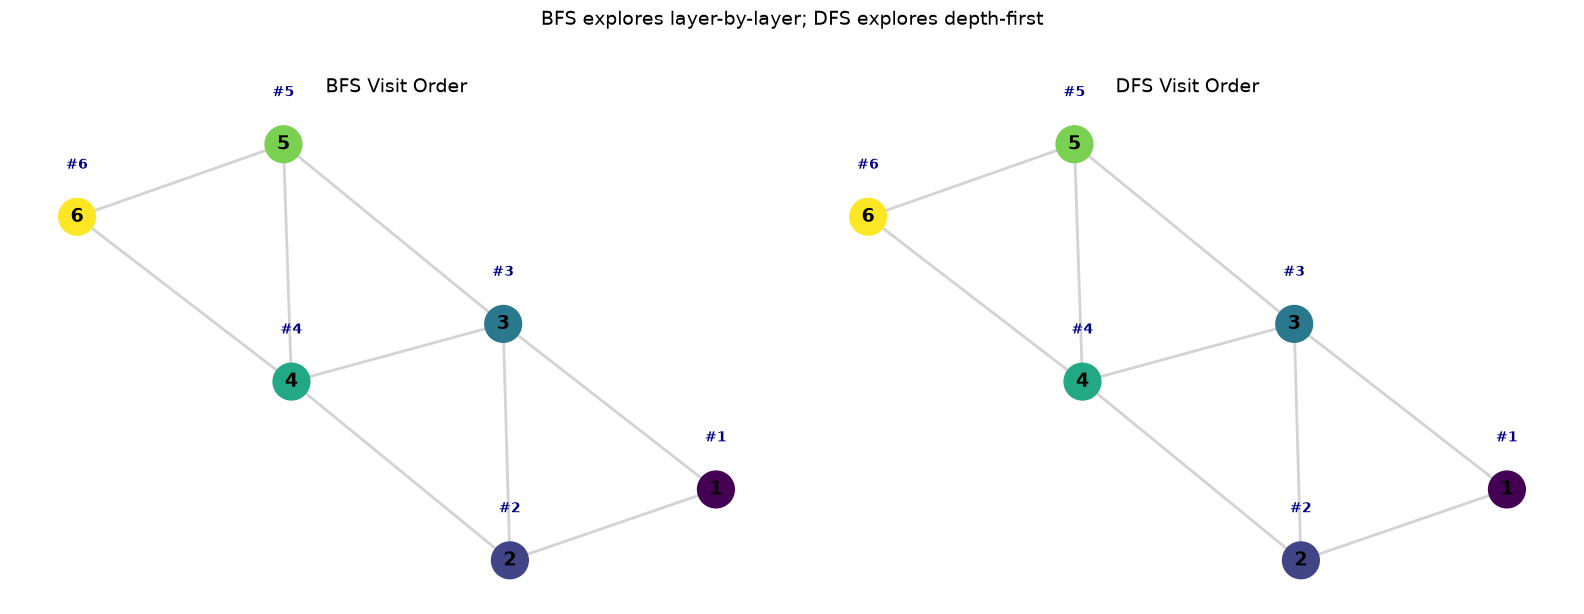

In [12]:
# Visualize BFS vs DFS side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# BFS order
bfs_color_map = {v: i for i, v in enumerate(bfs_order)}
bfs_colors = [bfs_color_map[v] for v in sorted(G.nodes())]
nx.draw(G, pos, ax=axes[0], with_labels=True,
        node_color=bfs_colors, cmap=plt.cm.viridis,
        node_size=700, font_size=14, font_weight='bold',
        edge_color='lightgray', width=2)
for v in G.nodes():
    x, y = pos[v]
    axes[0].text(x, y + 0.12, f'#{bfs_color_map[v]+1}', ha='center',
                fontsize=10, color='darkblue', fontweight='bold')
axes[0].set_title('BFS Visit Order', fontsize=14)

# DFS order
dfs_color_map = {v: i for i, v in enumerate(dfs_order)}
dfs_colors = [dfs_color_map[v] for v in sorted(G.nodes())]
nx.draw(G, pos, ax=axes[1], with_labels=True,
        node_color=dfs_colors, cmap=plt.cm.viridis,
        node_size=700, font_size=14, font_weight='bold',
        edge_color='lightgray', width=2)
for v in G.nodes():
    x, y = pos[v]
    axes[1].text(x, y + 0.12, f'#{dfs_color_map[v]+1}', ha='center',
                fontsize=10, color='darkblue', fontweight='bold')
axes[1].set_title('DFS Visit Order', fontsize=14)

plt.suptitle('BFS explores layer-by-layer; DFS explores depth-first',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## 4. Dijkstra's Shortest Path

Dijkstra's algorithm finds shortest paths in weighted graphs with non-negative edge weights.
We implement it from scratch using a heap, then visualize the result.

In [13]:
import heapq


def dijkstra(graph, source):
    """
    Dijkstra's shortest path algorithm.

    Parameters:
        graph: networkx weighted graph
        source: source vertex

    Returns:
        dist: dict mapping vertex -> shortest distance from source
        parent: dict mapping vertex -> parent on shortest path
    """
    dist = {v: float('inf') for v in graph.nodes()}
    parent = {v: None for v in graph.nodes()}
    dist[source] = 0

    # Priority queue: (distance, vertex)
    pq = [(0, source)]
    visited = set()

    while pq:
        d_u, u = heapq.heappop(pq)

        if u in visited:
            continue
        visited.add(u)

        for v in graph.neighbors(u):
            w = graph[u][v]['weight']
            if dist[u] + w < dist[v]:
                dist[v] = dist[u] + w
                parent[v] = u
                heapq.heappush(pq, (dist[v], v))

    return dist, parent


def reconstruct_path(parent, target):
    """Reconstruct shortest path from parent dict."""
    path = []
    v = target
    while v is not None:
        path.append(v)
        v = parent[v]
    return list(reversed(path))


# Run Dijkstra on the weighted graph from source A
dijk_dist, dijk_parent = dijkstra(W, source='A')

print("Dijkstra's shortest paths from A:")
print(f"{'Target':<10} {'Distance':<10} {'Path'}")
print("-" * 40)
for v in sorted(W.nodes()):
    path = reconstruct_path(dijk_parent, v)
    print(f"{v:<10} {dijk_dist[v]:<10} {' → '.join(path)}")

Dijkstra's shortest paths from A:
Target     Distance   Path
----------------------------------------
A          0          A
B          3          A → C → B
C          2          A → C
D          8          A → C → B → D
E          10         A → C → B → D → E
F          13         A → C → B → D → E → F


In [14]:
# Verify against NetworkX built-in
nx_dist = dict(nx.single_source_dijkstra_path_length(W, 'A'))
print("Verification against NetworkX:")
for v in sorted(W.nodes()):
    match = "✓" if abs(dijk_dist[v] - nx_dist[v]) < 1e-10 else "✗"
    print(f"  {v}: our={dijk_dist[v]}, nx={nx_dist[v]} {match}")

Verification against NetworkX:
  A: our=0, nx=0 ✓
  B: our=3, nx=3 ✓
  C: our=2, nx=2 ✓
  D: our=8, nx=8 ✓
  E: our=10, nx=10 ✓
  F: our=13, nx=13 ✓


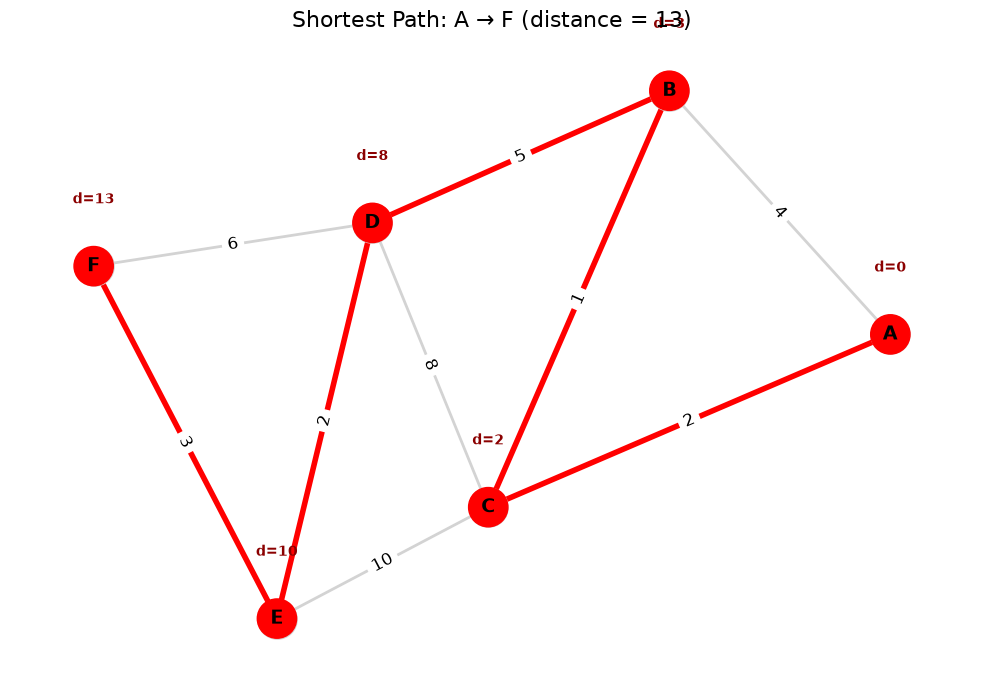

In [15]:
# Visualize shortest path from A to F
target = 'F'
shortest_path = reconstruct_path(dijk_parent, target)
shortest_path_edges = list(zip(shortest_path[:-1], shortest_path[1:]))

fig, ax = plt.subplots(1, 1, figsize=(10, 7))

# Draw all edges
nx.draw(W, pos_w, ax=ax, with_labels=True,
        node_color='lightgray', node_size=800, font_size=14, font_weight='bold',
        edge_color='lightgray', width=2)

# Highlight shortest path
path_nodes = shortest_path
node_colors = ['red' if v in path_nodes else 'lightgray' for v in W.nodes()]
nx.draw_networkx_nodes(W, pos_w, ax=ax, node_color=node_colors, node_size=800)
nx.draw_networkx_edges(W, pos_w, edgelist=shortest_path_edges, ax=ax,
                        edge_color='red', width=4)

# Edge weight labels
edge_labels = nx.get_edge_attributes(W, 'weight')
nx.draw_networkx_edge_labels(W, pos_w, edge_labels=edge_labels,
                              font_size=12, ax=ax)

# Distance labels
for v in W.nodes():
    x, y = pos_w[v]
    ax.text(x, y + 0.1, f'd={dijk_dist[v]}', ha='center',
            fontsize=10, color='darkred', fontweight='bold')

ax.set_title(f'Shortest Path: A → {target} (distance = {dijk_dist[target]})',
             fontsize=16)
plt.tight_layout()
plt.show()

---
## 5. Minimum Spanning Tree

A minimum spanning tree (MST) connects all vertices with minimum total edge weight.
We demonstrate both Kruskal's and Prim's algorithms.

In [16]:
def kruskal_mst(graph):
    """
    Kruskal's MST algorithm using Union-Find.

    Returns:
        mst_edges: list of (u, v, weight) in the MST
        total_weight: sum of edge weights in MST
    """
    # Union-Find data structure
    parent_uf = {v: v for v in graph.nodes()}
    rank = {v: 0 for v in graph.nodes()}

    def find(x):
        if parent_uf[x] != x:
            parent_uf[x] = find(parent_uf[x])  # Path compression
        return parent_uf[x]

    def union(x, y):
        px, py = find(x), find(y)
        if px == py:
            return False
        if rank[px] < rank[py]:
            px, py = py, px
        parent_uf[py] = px
        if rank[px] == rank[py]:
            rank[px] += 1
        return True

    # Sort edges by weight
    edges = [(data['weight'], u, v) for u, v, data in graph.edges(data=True)]
    edges.sort()

    mst_edges = []
    total_weight = 0

    print("Kruskal's algorithm — processing edges by weight:")
    for w, u, v in edges:
        if union(u, v):
            mst_edges.append((u, v, w))
            total_weight += w
            print(f"  ADD  ({u}, {v}) weight={w}  [total so far: {total_weight}]")
        else:
            print(f"  SKIP ({u}, {v}) weight={w}  [would create cycle]")

        if len(mst_edges) == graph.number_of_nodes() - 1:
            break

    return mst_edges, total_weight


mst_edges, mst_weight = kruskal_mst(W)
print(f"\nMST total weight: {mst_weight}")
print(f"MST has {len(mst_edges)} edges (= n-1 = {W.number_of_nodes()-1}) ✓")

Kruskal's algorithm — processing edges by weight:
  ADD  (B, C) weight=1  [total so far: 1]
  ADD  (A, C) weight=2  [total so far: 3]
  ADD  (D, E) weight=2  [total so far: 5]
  ADD  (E, F) weight=3  [total so far: 8]
  SKIP (A, B) weight=4  [would create cycle]
  ADD  (B, D) weight=5  [total so far: 13]

MST total weight: 13
MST has 5 edges (= n-1 = 5) ✓


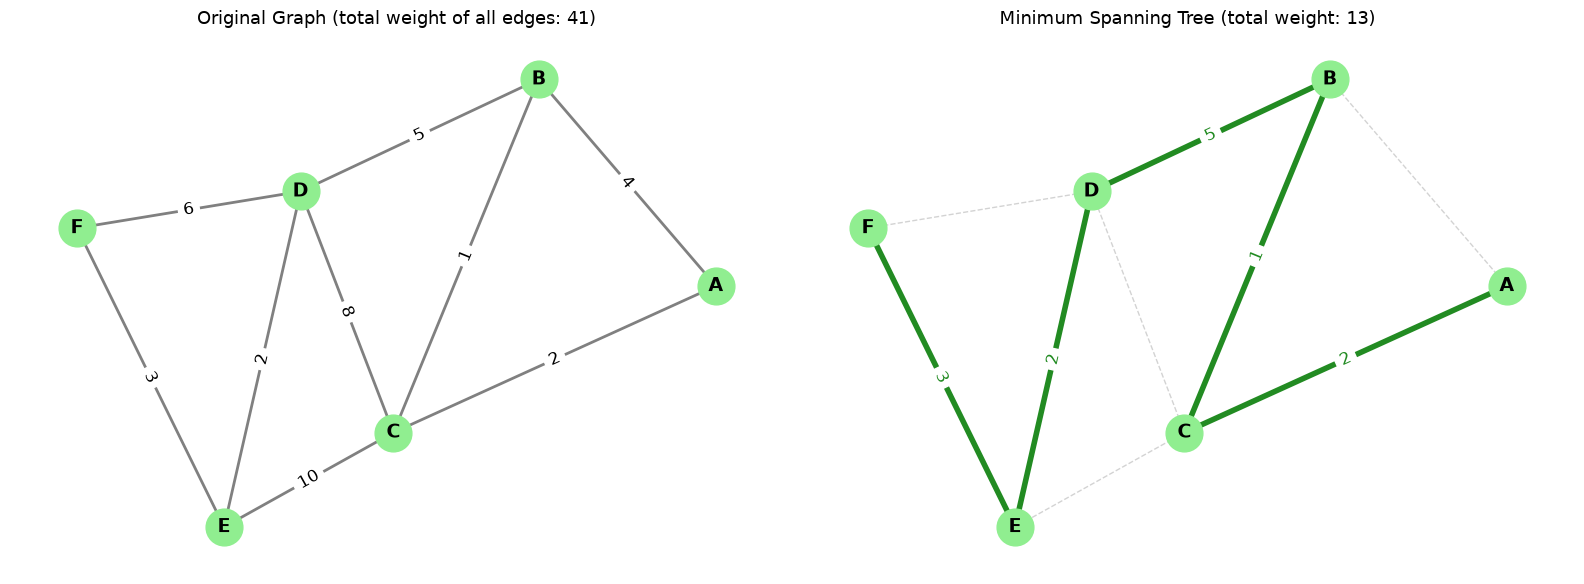


Verification — NetworkX MST weight: 13
Our MST weight: 13
Match: ✓


In [17]:
# Visualize MST
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Original graph
nx.draw(W, pos_w, ax=axes[0], with_labels=True,
        node_color='lightgreen', node_size=700, font_size=14, font_weight='bold',
        edge_color='gray', width=2)
edge_labels = nx.get_edge_attributes(W, 'weight')
nx.draw_networkx_edge_labels(W, pos_w, edge_labels=edge_labels,
                              font_size=12, ax=axes[0])
axes[0].set_title(f'Original Graph (total weight of all edges: '
                  f'{sum(d["weight"] for _, _, d in W.edges(data=True))})',
                  fontsize=13)

# MST
mst_edge_list = [(u, v) for u, v, _ in mst_edges]
nx.draw(W, pos_w, ax=axes[1], with_labels=True,
        node_color='lightgreen', node_size=700, font_size=14, font_weight='bold',
        edge_color='lightgray', width=1, style='dashed')
nx.draw_networkx_edges(W, pos_w, edgelist=mst_edge_list, ax=axes[1],
                        edge_color='forestgreen', width=4)

# Only show MST edge weights
mst_labels = {(u, v): w for u, v, w in mst_edges}
# Also check reversed edges
mst_labels_full = {}
for (u, v), w_val in edge_labels.items():
    if (u, v) in mst_labels or (v, u) in mst_labels:
        mst_labels_full[(u, v)] = w_val
nx.draw_networkx_edge_labels(W, pos_w, edge_labels=mst_labels_full,
                              font_size=12, font_color='forestgreen', ax=axes[1])
axes[1].set_title(f'Minimum Spanning Tree (total weight: {mst_weight})',
                  fontsize=13)

plt.tight_layout()
plt.show()

# Verify with NetworkX
nx_mst = nx.minimum_spanning_tree(W)
nx_mst_weight = sum(d['weight'] for _, _, d in nx_mst.edges(data=True))
print(f"\nVerification — NetworkX MST weight: {nx_mst_weight}")
print(f"Our MST weight: {mst_weight}")
print(f"Match: {'✓' if mst_weight == nx_mst_weight else '✗'}")

---
## 6. Real-World Network Example: Small Social Network

We analyze the Karate Club network — a classic social network dataset collected by
Wayne Zachary (1977). It represents friendships between 34 members of a university
karate club that eventually split into two groups due to a conflict between the
instructor (node 0) and the club president (node 33).

In [18]:
# Load the Karate Club graph (built into NetworkX)
K = nx.karate_club_graph()

print("Zachary's Karate Club Network:")
print(f"  Vertices (members): {K.number_of_nodes()}")
print(f"  Edges (friendships): {K.number_of_edges()}")
print(f"  Connected: {nx.is_connected(K)}")
print(f"  Diameter: {nx.diameter(K)}")
print(f"  Average clustering coefficient: {nx.average_clustering(K):.4f}")
print(f"  Average shortest path length: {nx.average_shortest_path_length(K):.4f}")

Zachary's Karate Club Network:
  Vertices (members): 34
  Edges (friendships): 78
  Connected: True
  Diameter: 5
  Average clustering coefficient: 0.5706
  Average shortest path length: 2.4082


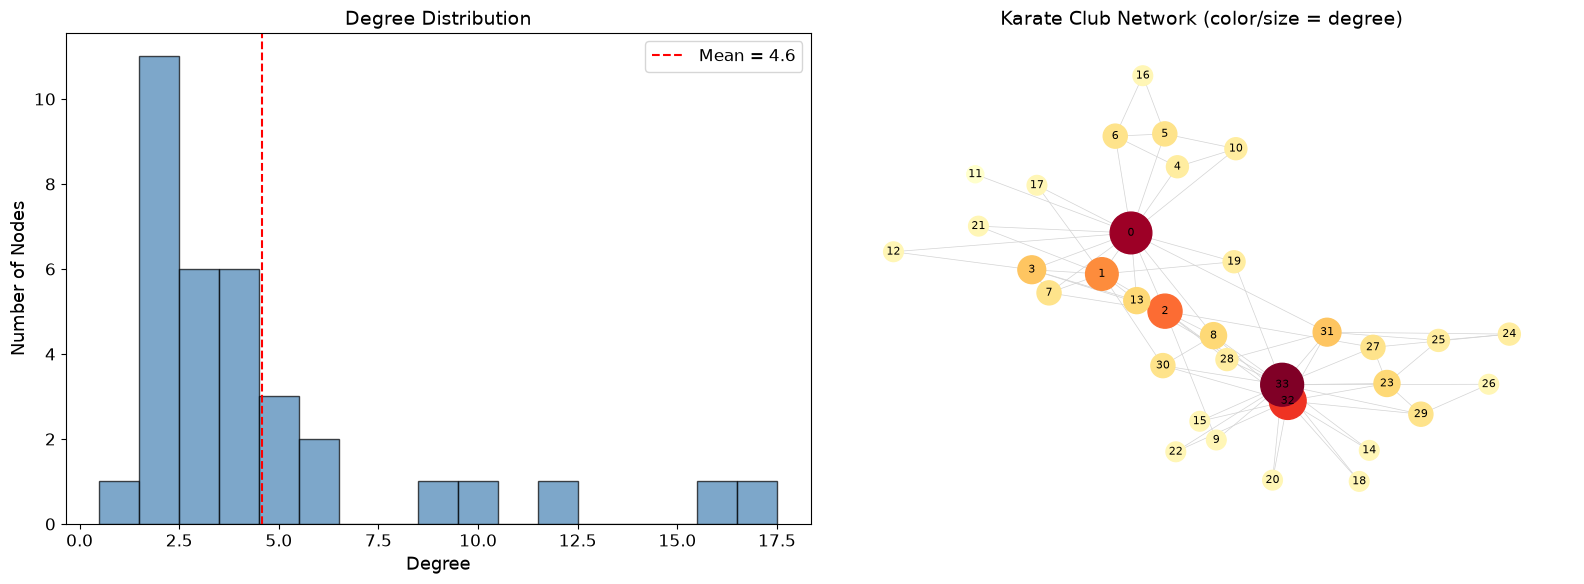


Handshaking Lemma: sum(degrees) = 156 = 2 × 78 = 156 ✓


In [19]:
# Degree distribution
degrees_karate = [d for _, d in K.degree()]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram
axes[0].hist(degrees_karate, bins=range(1, max(degrees_karate) + 2),
             edgecolor='black', color='steelblue', alpha=0.7, align='left')
axes[0].set_xlabel('Degree', fontsize=13)
axes[0].set_ylabel('Number of Nodes', fontsize=13)
axes[0].set_title('Degree Distribution', fontsize=14)
axes[0].axvline(np.mean(degrees_karate), color='red', linestyle='--',
                label=f'Mean = {np.mean(degrees_karate):.1f}')
axes[0].legend(fontsize=12)

# Network visualization colored by degree
pos_k = nx.spring_layout(K, seed=42)
node_sizes = [100 + 50 * K.degree(v) for v in K.nodes()]
node_colors = [K.degree(v) for v in K.nodes()]

im = nx.draw(K, pos_k, ax=axes[1], with_labels=True,
             node_color=node_colors, cmap=plt.cm.YlOrRd,
             node_size=node_sizes, font_size=8,
             edge_color='lightgray', width=0.5)
axes[1].set_title('Karate Club Network (color/size = degree)', fontsize=14)

plt.tight_layout()
plt.show()

# Handshaking lemma check
print(f"\nHandshaking Lemma: sum(degrees) = {sum(degrees_karate)} = "
      f"2 × {K.number_of_edges()} = {2 * K.number_of_edges()} ✓")

In [20]:
# Centrality analysis
degree_centrality = nx.degree_centrality(K)
betweenness = nx.betweenness_centrality(K)
closeness = nx.closeness_centrality(K)

print("Top 5 members by centrality measures:")
print(f"\n{'Rank':<6} {'Degree':<20} {'Betweenness':<20} {'Closeness':<20}")
print("-" * 66)

top_deg = sorted(degree_centrality, key=degree_centrality.get, reverse=True)[:5]
top_bet = sorted(betweenness, key=betweenness.get, reverse=True)[:5]
top_clo = sorted(closeness, key=closeness.get, reverse=True)[:5]

for i in range(5):
    d = f"Node {top_deg[i]} ({degree_centrality[top_deg[i]]:.3f})"
    b = f"Node {top_bet[i]} ({betweenness[top_bet[i]]:.3f})"
    c = f"Node {top_clo[i]} ({closeness[top_clo[i]]:.3f})"
    print(f"{i+1:<6} {d:<20} {b:<20} {c:<20}")

print("\nNodes 0 (instructor) and 33 (president) are the most central — ")
print("consistent with the known club structure.")

Top 5 members by centrality measures:

Rank   Degree               Betweenness          Closeness           
------------------------------------------------------------------
1      Node 33 (0.515)      Node 0 (0.438)       Node 0 (0.569)      
2      Node 0 (0.485)       Node 33 (0.304)      Node 2 (0.559)      
3      Node 32 (0.364)      Node 32 (0.145)      Node 33 (0.550)     
4      Node 2 (0.303)       Node 2 (0.144)       Node 31 (0.541)     
5      Node 1 (0.273)       Node 31 (0.138)      Node 8 (0.516)      

Nodes 0 (instructor) and 33 (president) are the most central — 
consistent with the known club structure.


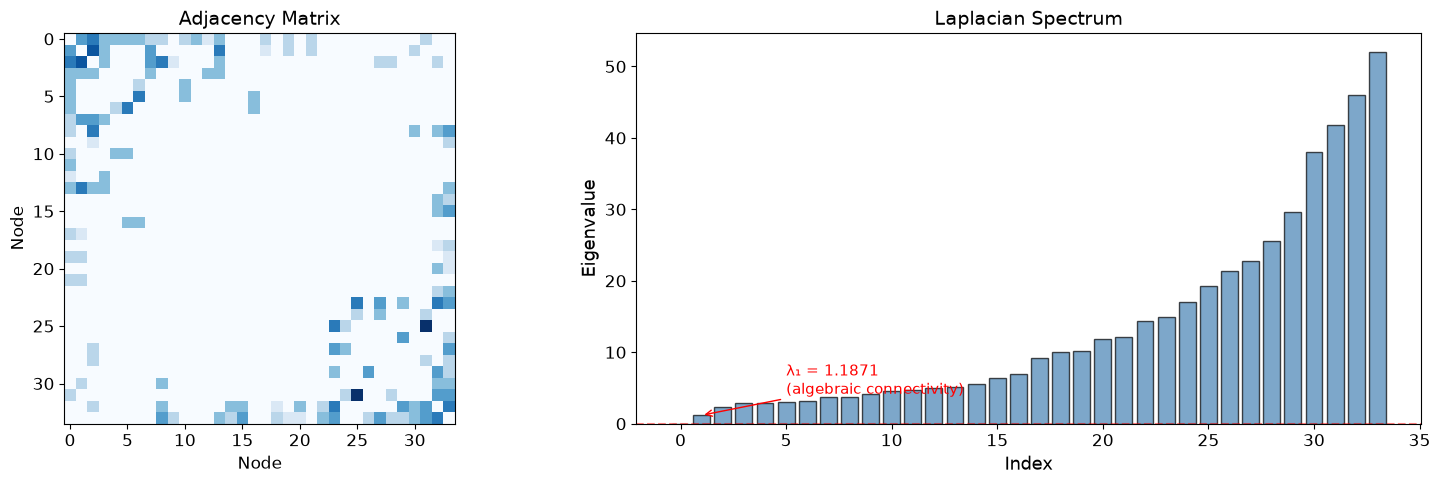

Algebraic connectivity (λ₁): 1.1871
Number of connected components = number of zero eigenvalues = 1

The Laplacian spectrum is directly used in:
  • Spectral clustering (community detection)
  • Graph signal processing
  • Graph Neural Networks (spectral convolutions)


In [21]:
# Adjacency matrix and its spectrum (connection to spectral graph theory / GNNs)
A_karate = nx.adjacency_matrix(K).toarray().astype(float)
D_karate = np.diag(A_karate.sum(axis=1))
L_karate = D_karate - A_karate

eigenvalues_karate = np.sort(np.linalg.eigvalsh(L_karate))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Adjacency matrix heatmap
axes[0].imshow(A_karate, cmap='Blues', aspect='equal')
axes[0].set_title('Adjacency Matrix', fontsize=14)
axes[0].set_xlabel('Node')
axes[0].set_ylabel('Node')

# Laplacian spectrum
axes[1].bar(range(len(eigenvalues_karate)), eigenvalues_karate,
            color='steelblue', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Index', fontsize=13)
axes[1].set_ylabel('Eigenvalue', fontsize=13)
axes[1].set_title('Laplacian Spectrum', fontsize=14)
axes[1].axhline(y=0, color='red', linestyle='--', alpha=0.5)

# Annotate algebraic connectivity
axes[1].annotate(f'λ₁ = {eigenvalues_karate[1]:.4f}\n(algebraic connectivity)',
                xy=(1, eigenvalues_karate[1]),
                xytext=(5, eigenvalues_karate[1] + 3),
                arrowprops=dict(arrowstyle='->', color='red'),
                fontsize=11, color='red')

plt.tight_layout()
plt.show()

print(f"Algebraic connectivity (λ₁): {eigenvalues_karate[1]:.4f}")
print(f"Number of connected components = number of zero eigenvalues = "
      f"{np.sum(eigenvalues_karate < 1e-10)}")
print("\nThe Laplacian spectrum is directly used in:")
print("  • Spectral clustering (community detection)")
print("  • Graph signal processing")
print("  • Graph Neural Networks (spectral convolutions)")

---
## 7. Special Graphs Gallery

Visualize the special graph classes from the theory.

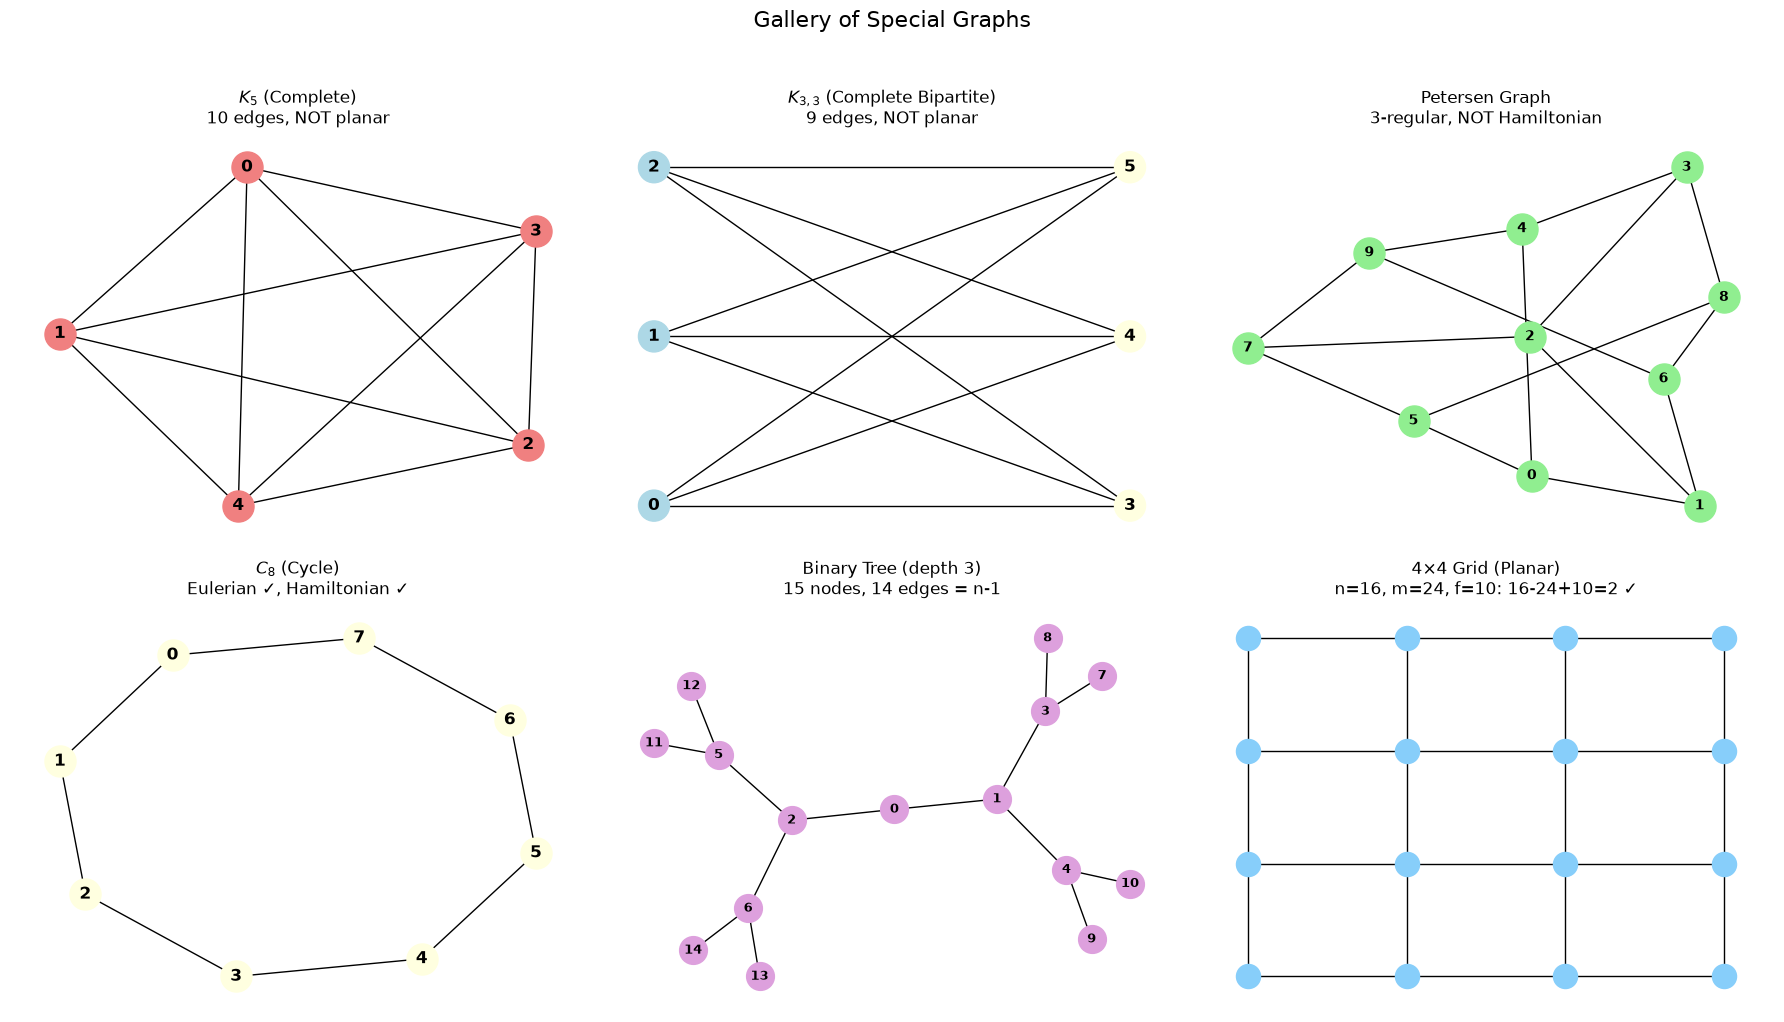

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# K5 (Complete graph)
K5 = nx.complete_graph(5)
nx.draw(K5, ax=axes[0, 0], with_labels=True, node_color='lightcoral',
        node_size=500, font_size=12, font_weight='bold')
axes[0, 0].set_title(f'$K_5$ (Complete)\n'
                     f'{K5.number_of_edges()} edges, NOT planar',
                     fontsize=12)

# K_{3,3} (Complete bipartite)
K33 = nx.complete_bipartite_graph(3, 3)
pos_bp = nx.bipartite_layout(K33, nodes=range(3))
colors_bp = ['lightblue'] * 3 + ['lightyellow'] * 3
nx.draw(K33, pos_bp, ax=axes[0, 1], with_labels=True, node_color=colors_bp,
        node_size=500, font_size=12, font_weight='bold')
axes[0, 1].set_title(f'$K_{{3,3}}$ (Complete Bipartite)\n'
                     f'{K33.number_of_edges()} edges, NOT planar',
                     fontsize=12)

# Petersen graph
P = nx.petersen_graph()
nx.draw(P, ax=axes[0, 2], with_labels=True, node_color='lightgreen',
        node_size=500, font_size=10, font_weight='bold')
axes[0, 2].set_title(f'Petersen Graph\n'
                     f'3-regular, NOT Hamiltonian',
                     fontsize=12)

# Cycle graph
C8 = nx.cycle_graph(8)
nx.draw(C8, ax=axes[1, 0], with_labels=True, node_color='lightyellow',
        node_size=500, font_size=12, font_weight='bold')
axes[1, 0].set_title(f'$C_8$ (Cycle)\nEulerian ✓, Hamiltonian ✓',
                     fontsize=12)

# Binary tree
T = nx.balanced_tree(r=2, h=3)
pos_tree = nx.nx_agraph.graphviz_layout(T, prog='dot') if False else nx.spring_layout(T, seed=1)
nx.draw(T, ax=axes[1, 1], with_labels=True, node_color='plum',
        node_size=400, font_size=9, font_weight='bold')
axes[1, 1].set_title(f'Binary Tree (depth 3)\n'
                     f'{T.number_of_nodes()} nodes, '
                     f'{T.number_of_edges()} edges = n-1',
                     fontsize=12)

# Grid / planar graph
Grid = nx.grid_2d_graph(4, 4)
pos_grid = {(i, j): (j, -i) for i, j in Grid.nodes()}
nx.draw(Grid, pos_grid, ax=axes[1, 2], with_labels=False, node_color='lightskyblue',
        node_size=300)
n_grid = Grid.number_of_nodes()
m_grid = Grid.number_of_edges()
f_grid = 2 + m_grid - n_grid  # Euler's formula: n - m + f = 2
axes[1, 2].set_title(f'4×4 Grid (Planar)\n'
                     f'n={n_grid}, m={m_grid}, f={f_grid}: '
                     f'{n_grid}-{m_grid}+{f_grid}=2 ✓',
                     fontsize=12)

plt.suptitle('Gallery of Special Graphs', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

---
## Summary

In this notebook we demonstrated:

| Concept | What We Did |
|---------|-------------|
| **Graph construction** | Built undirected, directed, and weighted graphs with NetworkX |
| **Adjacency matrix** | Computed $A$, verified symmetry, demonstrated walk-counting via $A^k$ |
| **Laplacian** | Computed $L = D - A$, examined spectrum for connectivity |
| **BFS** | Implemented from scratch, found shortest distances in unweighted graph |
| **DFS** | Implemented from scratch, compared traversal order with BFS |
| **Dijkstra** | Implemented with heap, found shortest paths in weighted graph, verified against NetworkX |
| **MST** | Implemented Kruskal's algorithm with Union-Find, verified against NetworkX |
| **Real network** | Analyzed Zachary's Karate Club: degree distribution, centrality, Laplacian spectrum |
| **Special graphs** | Visualized $K_5$, $K_{3,3}$, Petersen, cycle, tree, and grid graphs |